# Segment 2 — LiDAR Processing & Visualization

Loads a KITTI/SemanticKITTI-style `.bin` LiDAR frame, cleans it, applies distance/ROI filters, separates ground/non-ground points, and visualizes the result with Open3D.

In [1]:
# Install dependencies if needed
!pip install numpy open3d -q

In [2]:
import os
import numpy as np
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# Configuration
FILE_PATH = "fake_lidar_000000.bin"
MAX_DISTANCE = 100.0
GROUND_HEIGHT = 0.2

print("LiDAR file:", FILE_PATH)

LiDAR file: fake_lidar_000000.bin


In [4]:
def load_lidar(file_path):
    """Load a KITTI/SemanticKITTI-style .bin file: x, y, z, intensity."""
    points = np.fromfile(file_path, dtype=np.float32)
    if len(points) % 4 != 0:
        raise ValueError("Invalid LiDAR file: values are not divisible by 4.")
    points = points.reshape(-1, 4)
    return points[:, :3], points[:, 3]


def remove_invalid_points(xyz, intensity):
    mask = np.isfinite(xyz).all(axis=1) & np.isfinite(intensity)
    return xyz[mask], intensity[mask]


def filter_distance(xyz, intensity, max_distance=100.0):
    distance = np.linalg.norm(xyz, axis=1)
    mask = distance <= max_distance
    return xyz[mask], intensity[mask]


def filter_roi(xyz, intensity, x_min=-10, x_max=100,
               y_min=-50, y_max=50, z_min=-3, z_max=5):
    mask = (
        (xyz[:, 0] >= x_min) & (xyz[:, 0] <= x_max) &
        (xyz[:, 1] >= y_min) & (xyz[:, 1] <= y_max) &
        (xyz[:, 2] >= z_min) & (xyz[:, 2] <= z_max)
    )
    return xyz[mask], intensity[mask]


def separate_ground(xyz, intensity, ground_height=0.2):
    ground_mask = xyz[:, 2] < ground_height
    return (
        xyz[ground_mask], intensity[ground_mask],
        xyz[~ground_mask], intensity[~ground_mask]
    )


def voxel_downsample(xyz, voxel_size=0.10):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    downsampled = pcd.voxel_down_sample(voxel_size)
    return np.asarray(downsampled.points)


def create_cloud(xyz):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    return pcd


def visualize_ground_and_objects(ground_xyz, object_xyz):
    ground = create_cloud(ground_xyz)
    objects = create_cloud(object_xyz)
   
    ground.paint_uniform_color([0.3, 0.8, 0.3])
    objects.paint_uniform_color([0.9, 0.2, 0.2])
    o3d.visualization.draw_geometries(
        [ground, objects], window_name="LiDAR Point Cloud"
    )

In [5]:
# Run the complete processing pipeline
if not os.path.exists(FILE_PATH):
    print(f"File not found: {FILE_PATH}")
    print("Upload/create the data/000000.bin file, then run this cell again.")
else:
    print("=" * 45)
    print("        LiDAR PROCESSOR")
    print("=" * 45)

    xyz, intensity = load_lidar(FILE_PATH)
    print("Raw points:", len(xyz))

    xyz, intensity = remove_invalid_points(xyz, intensity)
    print("After invalid filtering:", len(xyz))

    xyz, intensity = filter_distance(xyz, intensity, MAX_DISTANCE)
    print("After distance filtering:", len(xyz))

    xyz, intensity = filter_roi(xyz, intensity)
    print("After ROI filtering:", len(xyz))

    ground_xyz, ground_intensity, object_xyz, object_intensity = separate_ground(
        xyz, intensity, GROUND_HEIGHT
    )

    print("\nGround points:", len(ground_xyz))
    print("Non-ground points:", len(object_xyz))
   
    print("\nOpening 3D viewer...")
    visualize_ground_and_objects(ground_xyz, object_xyz)
    print("Processing complete.")

        LiDAR PROCESSOR
Raw points: 71000
After invalid filtering: 71000
After distance filtering: 69167
After ROI filtering: 65631

Ground points: 45872
Non-ground points: 19759

Opening 3D viewer...
Processing complete.


## Notes

- The `z < 0.2` ground separator is only a prototype and will not robustly handle slopes or uneven terrain.
- The next milestone is replacing it with a better ground segmentation method and then moving to object detection/segmentation.

# Segment 3 — LiDAR Semantic Segmentation

Prototype pipeline: **LiDAR (x, y, z, intensity) → point-wise class + confidence**.

Classes: Road, Non-drivable Terrain, Vehicle, Pedestrian, Building/Wall, Pole, Vegetation, Unknown.

In [6]:
!pip install numpy torch open3d matplotlib -q

In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import open3d as o3d

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [8]:
CLASS_NAMES = {
    0: 'Road',
    1: 'Non-drivable Terrain',
    2: 'Vehicle',
    3: 'Pedestrian',
    4: 'Building/Wall',
    5: 'Pole',
    6: 'Vegetation',
    7: 'Unknown'
}

NUM_CLASSES = len(CLASS_NAMES)
for k, v in CLASS_NAMES.items(): print(k, '→', v)

0 → Road
1 → Non-drivable Terrain
2 → Vehicle
3 → Pedestrian
4 → Building/Wall
5 → Pole
6 → Vegetation
7 → Unknown


## 1. Load LiDAR `.bin` file

In [9]:
def load_lidar_bin(path):
    data = np.fromfile(path, dtype=np.float32)
    if data.size % 4 != 0:
        raise ValueError('Expected float32 x,y,z,intensity values.')
    return data.reshape(-1, 4)

LIDAR_PATH = 'data/000000.bin'

if os.path.exists(LIDAR_PATH):
    points = load_lidar_bin(LIDAR_PATH)
    print('Point cloud shape:', points.shape)
    print(points[:5])
else:
    print('File not found:', LIDAR_PATH)
    print('Put your .bin file inside data/ and update LIDAR_PATH.')

File not found: data/000000.bin
Put your .bin file inside data/ and update LIDAR_PATH.


In [10]:
def normalize_points(points):
    xyz = points[:, :3].astype(np.float32)
    intensity = points[:, 3:4].astype(np.float32)
    xyz = xyz - np.mean(xyz, axis=0)
    scale = np.max(np.linalg.norm(xyz, axis=1))
    if scale > 0:
        xyz = xyz / scale
    return np.concatenate([xyz, intensity], axis=1).astype(np.float32)

## 2. PointNet-style segmentation model

In [11]:
class PointNetSegmentation(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(4, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 256, 1)
        self.conv4 = nn.Conv1d(384, 256, 1)
        self.conv5 = nn.Conv1d(256, 128, 1)
        self.conv6 = nn.Conv1d(128, num_classes, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)
        self.bn4 = nn.BatchNorm1d(256)
        self.bn5 = nn.BatchNorm1d(128)

    def forward(self, x):
        x = x.transpose(2, 1)
        x1 = F.relu(self.bn1(self.conv1(x)))
        x2 = F.relu(self.bn2(self.conv2(x1)))
        x3 = F.relu(self.bn3(self.conv3(x2)))
        global_feature = torch.max(x3, dim=2, keepdim=True)[0]
        global_feature = global_feature.repeat(1, 1, x.shape[2])
        features = torch.cat([x2, global_feature], dim=1)
        features = F.relu(self.bn4(self.conv4(features)))
        features = F.relu(self.bn5(self.conv5(features)))
        return self.conv6(features).transpose(2, 1)

model = PointNetSegmentation(NUM_CLASSES).to(device)
print('Model ready.')

Model ready.


## 3. Labeled dataset loader

In [12]:
class LidarDataset(Dataset):
    def __init__(self, point_files, label_files, num_points=4096):
        if len(point_files) != len(label_files):
            raise ValueError('Point and label file counts must match.')
        self.point_files = point_files
        self.label_files = label_files
        self.num_points = num_points

    def __len__(self): return len(self.point_files)

    def __getitem__(self, idx):
        points = load_lidar_bin(self.point_files[idx])
        labels = np.fromfile(self.label_files[idx], dtype=np.int32)
        if len(points) != len(labels):
            raise ValueError('Point/label count mismatch.')
        indices = np.random.choice(len(points), self.num_points,
                                   replace=len(points) < self.num_points)
        return (torch.tensor(normalize_points(points[indices]), dtype=torch.float32),
                torch.tensor(labels[indices], dtype=torch.long))

## 4. Training

Set `RUN_TRAINING = True` only after adding correctly labeled training data.

In [13]:
POINT_FILES = ['dataset/points/000000.bin', 'dataset/points/000001.bin']
LABEL_FILES = ['dataset/labels/000000.label', 'dataset/labels/000001.label']
RUN_TRAINING = False

if RUN_TRAINING:
    dataset = LidarDataset(POINT_FILES, LABEL_FILES, num_points=4096)
    loader = DataLoader(dataset, batch_size=8, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    EPOCHS = 20

    for epoch in range(EPOCHS):
        model.train(); total_loss = 0.0
        for batch_points, batch_labels in loader:
            batch_points, batch_labels = batch_points.to(device), batch_labels.to(device)
            output = model(batch_points)
            loss = criterion(output.reshape(-1, NUM_CLASSES), batch_labels.reshape(-1))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(loader):.4f}')

    torch.save(model.state_dict(), 'lidar_segmentation_model.pth')
    print('Saved lidar_segmentation_model.pth')
else:
    print('Training OFF — add labeled data first.')

Training OFF — add labeled data first.


## 5. Load trained model

In [14]:
MODEL_PATH = 'lidar_segmentation_model.pth'
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print('Trained model loaded.')
else:
    print('No trained model found.')

No trained model found.


## 6. Predict class + confidence

In [15]:
def predict_lidar(model, points):
    model.eval()
    x = torch.tensor(normalize_points(points), dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(x)
        probabilities = torch.softmax(output, dim=-1)
        confidence, predictions = torch.max(probabilities, dim=-1)
    return predictions.cpu().numpy()[0], confidence.cpu().numpy()[0]

if 'points' in globals():
    predictions, confidence = predict_lidar(model, points)
   
    for i in range(min(20, len(points))):
        print(f'Point {i:5d}: {CLASS_NAMES[int(predictions[i])]:20s} | confidence = {confidence[i]:.3f}')

In [16]:
if 'points' in globals() and 'predictions' in globals():
    result = np.column_stack([points, predictions, confidence])
    np.save('frame_predictions.npy', result)
    print('Saved: frame_predictions.npy')
    print('Columns: x, y, z, intensity, class_id, confidence')

## 7. Visualize segmentation

In [17]:
def visualize_prediction(points, predictions):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points[:, :3])
    class_colors = {
        0:[0.2,0.8,0.2], 1:[0.7,0.7,0.2], 2:[0.9,0.1,0.1],
        3:[0.1,0.1,0.9], 4:[0.6,0.4,0.2], 5:[0.8,0.2,0.8],
        6:[0.1,0.6,0.1], 7:[0.5,0.5,0.5]
    }
    colors = np.zeros((len(points), 3))
    for class_id, color in class_colors.items():
        colors[predictions == class_id] = color
    pcd.colors = o3d.utility.Vector3dVector(colors)
    o3d.visualization.draw_geometries([pcd], window_name='LiDAR Semantic Segmentation')

if 'points' in globals() and 'predictions' in globals():
    visualize_prediction(points, predictions)

## Segment 3 target

**Input:** `(x, y, z, intensity)`

**Output:** `point → class → confidence`

The resulting `frame_predictions.npy` is the handoff to Segment 4, where labeled points are grouped into actual objects.

# Segment 4 — LiDAR Classified Points to Objects

This notebook converts **classified LiDAR points** into structured objects.

Pipeline:

`classified points → separate classes → DBSCAN clustering → object properties → JSON output`

For now, the notebook uses synthetic classified LiDAR data so Segment 4 can be tested independently. Later, replace the sample data cell with the real output from Segment 3.


## 1. Install dependencies

In [18]:
%pip install -q numpy pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [19]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

## 3. Define semantic classes

In [20]:
CLASS_NAMES = {
    0: "road",
    1: "vehicle",
    2: "pedestrian",
    3: "pole",
    4: "wall",
    5: "grass",
    6: "rock"
}

DYNAMIC_PROBABILITY = {
    "vehicle": 0.90,
    "pedestrian": 0.98,
    "pole": 0.01,
    "wall": 0.01,
    "road": 0.00,
    "grass": 0.05,
    "rock": 0.02
}

## 4. Create example classified LiDAR data

Each LiDAR point has:

- `x, y, z`
- semantic class label
- classification confidence

Replace this cell later with the real output of Segment 3.


In [21]:
np.random.seed(42)

# Vehicle 1
vehicle1 = np.random.normal(
    loc=[10, 5, 1],
    scale=[0.8, 0.4, 0.3],
    size=(300, 3)
)

# Vehicle 2
vehicle2 = np.random.normal(
    loc=[25, -4, 1],
    scale=[0.8, 0.4, 0.3],
    size=(300, 3)
)

# Pedestrian
pedestrian = np.random.normal(
    loc=[18, 2, 1],
    scale=[0.15, 0.15, 0.45],
    size=(100, 3)
)

# Pole
pole = np.random.normal(
    loc=[30, 8, 2],
    scale=[0.07, 0.07, 0.8],
    size=(100, 3)
)

points = np.vstack([
    vehicle1,
    vehicle2,
    pedestrian,
    pole
])

labels = np.concatenate([
    np.full(len(vehicle1), 1),
    np.full(len(vehicle2), 1),
    np.full(len(pedestrian), 2),
    np.full(len(pole), 3)
])

confidence = np.random.uniform(
    0.85,
    0.99,
    len(points)
)

print("Total points:", len(points))
print("Points shape:", points.shape)
print("Labels shape:", labels.shape)
print("Confidence shape:", confidence.shape)

Total points: 800
Points shape: (800, 3)
Labels shape: (800,)
Confidence shape: (800,)


## 5. Visualize classified points

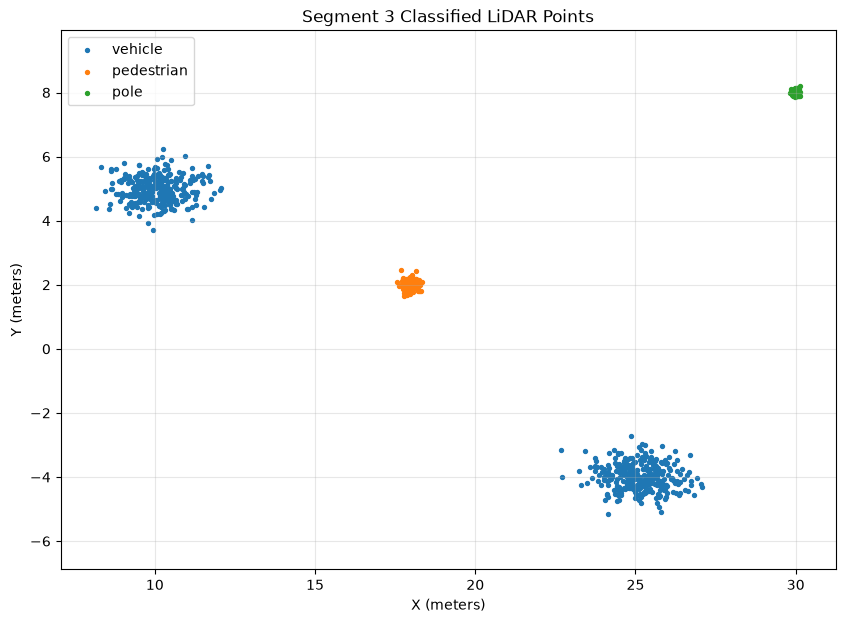

In [22]:
plt.figure(figsize=(10, 7))

for class_id, class_name in CLASS_NAMES.items():
    mask = labels == class_id

    if np.any(mask):
        plt.scatter(
            points[mask, 0],
            points[mask, 1],
            s=8,
            label=class_name
        )

plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title("Segment 3 Classified LiDAR Points")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

## 6. Separate points by semantic class

In [23]:
def separate_classes(points, labels, confidence):
    class_points = {}

    for class_id, class_name in CLASS_NAMES.items():
        mask = labels == class_id

        if np.any(mask):
            class_points[class_name] = {
                "points": points[mask],
                "confidence": confidence[mask]
            }

    return class_points


class_points = separate_classes(points, labels, confidence)

for class_name, data in class_points.items():
    print(f"{class_name:12s}: {len(data['points'])} points")

vehicle     : 600 points
pedestrian  : 100 points
pole        : 100 points


## 7. DBSCAN clustering

DBSCAN groups nearby semantic points into individual object instances.

For example, 600 points labelled `vehicle` can become:

- Vehicle 1
- Vehicle 2


In [24]:
def cluster_points(points, eps=1.0, min_samples=10):
    if len(points) == 0:
        return np.array([])

    clustering = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    return clustering.fit_predict(points)

## 8. Extract clusters

In [25]:
def extract_clusters(
    points,
    confidences,
    eps=1.0,
    min_samples=10
):
    cluster_labels = cluster_points(
        points,
        eps=eps,
        min_samples=min_samples
    )

    clusters = []

    for cluster_id in sorted(set(cluster_labels)):
        # DBSCAN uses -1 for noise
        if cluster_id == -1:
            continue

        mask = cluster_labels == cluster_id

        clusters.append({
            "cluster_id": int(cluster_id),
            "points": points[mask],
            "confidence": confidences[mask]
        })

    return clusters

## 9. Calculate object position, dimensions and confidence

In [26]:
def calculate_object_properties(cluster):
    pts = cluster["points"]
    conf = cluster["confidence"]

    # Object center
    center = np.mean(pts, axis=0)

    # Axis-aligned bounding box
    min_xyz = np.min(pts, axis=0)
    max_xyz = np.max(pts, axis=0)

    dimensions = max_xyz - min_xyz

    # Mean point confidence
    object_confidence = np.mean(conf)

    return {
        "position": center,
        "dimensions": dimensions,
        "confidence": object_confidence,
        "num_points": len(pts)
    }

## 10. Detect objects

In [27]:
def detect_objects(
    points,
    labels,
    confidence,
    eps=1.0,
    min_samples=10
):
    objects = []

    class_points = separate_classes(
        points,
        labels,
        confidence
    )

    object_id = 0

    # Terrain is handled separately and not clustered as discrete objects.
    terrain_classes = {"road", "grass", "rock"}

    for class_name, data in class_points.items():

        if class_name in terrain_classes:
            continue

        clusters = extract_clusters(
            data["points"],
            data["confidence"],
            eps=eps,
            min_samples=min_samples
        )

        for cluster in clusters:
            properties = calculate_object_properties(cluster)

            obj = {
                "id": object_id,
                "class": class_name,
                "position": properties["position"].tolist(),
                "dimensions": properties["dimensions"].tolist(),
                "confidence": float(properties["confidence"]),
                "dynamic_probability": DYNAMIC_PROBABILITY.get(class_name, 0.0),
                "num_points": properties["num_points"]
            }

            objects.append(obj)
            object_id += 1

    return objects


objects = detect_objects(
    points,
    labels,
    confidence,
    eps=1.0,
    min_samples=10
)

print("Detected objects:", len(objects))

Detected objects: 4


## 11. Print detected objects

In [28]:
for obj in objects:
    print("-" * 50)
    print("Object ID:", obj["id"])
    print("Class:", obj["class"])
    print("Position (x,y,z):", np.round(obj["position"], 2))
    print("Dimensions (L,W,H):", np.round(obj["dimensions"], 2))
    print("Confidence:", round(obj["confidence"] * 100, 2), "%")
    print("Dynamic probability:", obj["dynamic_probability"])
    print("Number of points:", obj["num_points"])

--------------------------------------------------
Object ID: 0
Class: vehicle
Position (x,y,z): [10.05  4.97  1.02]
Dimensions (L,W,H): [3.9  2.53 1.95]
Confidence: 91.79 %
Dynamic probability: 0.9
Number of points: 300
--------------------------------------------------
Object ID: 1
Class: vehicle
Position (x,y,z): [25.14 -3.99  1.01]
Dimensions (L,W,H): [4.38 2.45 1.63]
Confidence: 92.05 %
Dynamic probability: 0.9
Number of points: 300
--------------------------------------------------
Object ID: 2
Class: pedestrian
Position (x,y,z): [17.99  2.01  0.98]
Dimensions (L,W,H): [0.78 0.82 2.55]
Confidence: 91.89 %
Dynamic probability: 0.98
Number of points: 100
--------------------------------------------------
Object ID: 3
Class: pole
Position (x,y,z): [30.    8.    1.99]
Dimensions (L,W,H): [0.33 0.37 4.01]
Confidence: 91.83 %
Dynamic probability: 0.01
Number of points: 100


## 12. Show results as a table

In [29]:
rows = []

for obj in objects:
    rows.append({
        "ID": obj["id"],
        "Class": obj["class"],
        "X": obj["position"][0],
        "Y": obj["position"][1],
        "Z": obj["position"][2],
        "Length": obj["dimensions"][0],
        "Width": obj["dimensions"][1],
        "Height": obj["dimensions"][2],
        "Confidence": obj["confidence"],
        "Dynamic Probability": obj["dynamic_probability"],
        "Points": obj["num_points"]
    })

objects_df = pd.DataFrame(rows)
objects_df.round(3)

,ID,Class,X,Y,Z,Length,Width,Height,Confidence,Dynamic Probability,Points
0,0,vehicle,10.054,4.971,1.019,3.900,2.528,1.951,0.918,0.90,300
1,1,vehicle,25.140,-3.995,1.013,4.381,2.446,1.631,0.921,0.90,300
2,2,pedestrian,17.987,2.010,0.978,0.776,0.815,2.549,0.919,0.98,100
3,3,pole,30.000,7.998,1.992,0.326,0.368,4.013,0.918,0.01,100


## 13. Visualize detected object centers

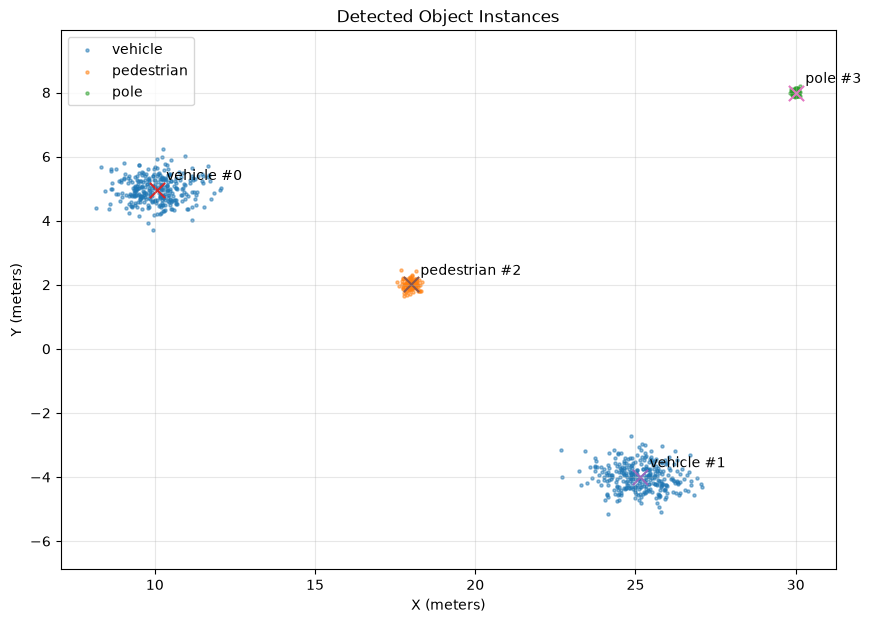

In [30]:
plt.figure(figsize=(10, 7))

for class_id, class_name in CLASS_NAMES.items():
    mask = labels == class_id

    if np.any(mask):
        plt.scatter(
            points[mask, 0],
            points[mask, 1],
            s=5,
            alpha=0.5,
            label=class_name
        )

for obj in objects:
    x, y, z = obj["position"]

    plt.scatter(
        x,
        y,
        marker="x",
        s=120
    )

    plt.text(
        x + 0.3,
        y + 0.3,
        f'{obj["class"]} #{obj["id"]}'
    )

plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title("Detected Object Instances")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

## 14. Create Segment 4 JSON output

In [31]:
segment4_output = {
    "timestamp": 123.42,
    "objects": objects
}

json_output = json.dumps(
    segment4_output,
    indent=4
)

print(json_output)

{
    "timestamp": 123.42,
    "objects": [
        {
            "id": 0,
            "class": "vehicle",
            "position": [
                10.053591406114869,
                4.970513384234874,
                1.0185648578644035
            ],
            "dimensions": [
                3.900224774388356,
                2.528059259409724,
                1.9511103897143196
            ],
            "confidence": 0.9179266065923876,
            "dynamic_probability": 0.9,
            "num_points": 300
        },
        {
            "id": 1,
            "class": "vehicle",
            "position": [
                25.140482229424126,
                -3.9948415760910763,
                1.0133249052246427
            ],
            "dimensions": [
                4.380771772678408,
                2.4457832205357874,
                1.6314318787946067
            ],
            "confidence": 0.9205039057084067,
            "dynamic_probability": 0.9,
            "num_points"

## 15. Save structured object data

In [32]:
output_file = "segment4_objects.json"

with open(output_file, "w") as f:
    json.dump(
        segment4_output,
        f,
        indent=4
    )

print("Saved:", output_file)

Saved: segment4_objects.json


## Next step

Once this works with real Segment 3 classified LiDAR points, Segment 5 can consume the structured objects and terrain data to construct the **2.5D map**.

For real data, replace the synthetic-data cell with arrays shaped like:

```python
points.shape      # (N, 3)
labels.shape      # (N,)
confidence.shape  # (N,)
```

where every row of `points` is `[x, y, z]`.


# Segment 5 — 2.5D Semantic Elevation Map

This notebook implements the fixed-resolution map described in the supplied Segment 5 notes:

**Classified LiDAR points → 2.5D grid**

Each cell stores:
- elevation
- minimum/maximum height
- semantic class
- semantic confidence
- occupancy
- dynamic probability
- point count
- timestamp

The adaptive/foveated resolution is intentionally **not** implemented here; that belongs to Segment 6.


In [33]:
# 1. Imports and configuration

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from collections import defaultdict
from datetime import datetime

# Fixed resolution for Segment 5
RESOLUTION = 0.05       # 5 cm
MAP_SIZE_X = 100.0      # metres
MAP_SIZE_Y = 100.0      # metres

# Coordinate convention:
# x = forward
# y = left/right
# z = height

print(f"Resolution: {RESOLUTION} m")
print(f"Map size: {MAP_SIZE_X} m x {MAP_SIZE_Y} m")


Resolution: 0.05 m
Map size: 100.0 m x 100.0 m


In [34]:
# 2. MapCell data structure

@dataclass
class MapCell:
    elevation: float = np.nan
    min_height: float = np.nan
    max_height: float = np.nan

    semantic_class: str = "UNKNOWN"
    semantic_confidence: float = 0.0

    occupancy: float = 0.0
    dynamic_probability: float = 0.0

    point_count: int = 0
    timestamp: float = 0.0

    # Internal accumulators
    heights: list = field(default_factory=list)
    semantic_votes: dict = field(default_factory=lambda: defaultdict(float))
    dynamic_votes: list = field(default_factory=list)

    def add_point(self, z, label="UNKNOWN", confidence=1.0,
                  dynamic_probability=0.0, timestamp=None):
        self.heights.append(float(z))

        # Confidence-weighted semantic voting
        self.semantic_votes[str(label)] += float(confidence)

        self.dynamic_votes.append(float(dynamic_probability))

        self.point_count += 1

        if timestamp is not None:
            self.timestamp = float(timestamp)

    def finalize(self):
        if not self.heights:
            return

        z = np.asarray(self.heights, dtype=float)

        self.min_height = float(np.min(z))
        self.max_height = float(np.max(z))

        # Mean elevation for the first implementation
        self.elevation = float(np.mean(z))

        # Confidence-weighted semantic class
        if self.semantic_votes:
            self.semantic_class = max(
                self.semantic_votes,
                key=self.semantic_votes.get
            )

            total = sum(self.semantic_votes.values())
            self.semantic_confidence = (
                self.semantic_votes[self.semantic_class] / total
                if total > 0 else 0.0
            )

        # Average dynamic probability
        if self.dynamic_votes:
            self.dynamic_probability = float(np.mean(self.dynamic_votes))

        # Simple occupancy probability
        self.occupancy = 1.0


In [35]:
# 3. Grid creation

class SemanticElevationGrid:
    def __init__(self, size_x, size_y, resolution):
        self.size_x = float(size_x)
        self.size_y = float(size_y)
        self.resolution = float(resolution)

        self.width = int(np.ceil(size_x / resolution))
        self.height = int(np.ceil(size_y / resolution))

        # Dictionary is memory-efficient for sparse LiDAR observations.
        self.cells = {}

    def world_to_grid(self, x, y):
        gx = int(np.floor(x / self.resolution))
        gy = int(np.floor(y / self.resolution))

        return gx, gy

    def grid_to_world(self, gx, gy):
        x = (gx + 0.5) * self.resolution
        y = (gy + 0.5) * self.resolution

        return x, y

    def get_cell(self, gx, gy):
        if not (0 <= gx < self.width and 0 <= gy < self.height):
            return None

        key = (gx, gy)

        if key not in self.cells:
            self.cells[key] = MapCell()

        return self.cells[key]

    def add_point(self, point, label="UNKNOWN", confidence=1.0,
                  dynamic_probability=0.0, timestamp=None):
        x, y, z = point[:3]

        gx, gy = self.world_to_grid(x, y)
        cell = self.get_cell(gx, gy)

        if cell is not None:
            cell.add_point(
                z=z,
                label=label,
                confidence=confidence,
                dynamic_probability=dynamic_probability,
                timestamp=timestamp
            )

    def finalize(self):
        for cell in self.cells.values():
            cell.finalize()

    def observed_mask(self):
        mask = np.zeros((self.height, self.width), dtype=bool)

        for gx, gy in self.cells:
            mask[gy, gx] = True

        return mask

print("Grid class ready.")


Grid class ready.


In [36]:
# 4. Example classified LiDAR data

# In the real project, replace this with the output from Segment 4.
#
# Columns:
# x, y, z, label, confidence, dynamic_probability

rng = np.random.default_rng(42)

points = []
labels = []
confidences = []
dynamic_probs = []

# Road / ground
for _ in range(3000):
    x = rng.uniform(0, 40)
    y = rng.uniform(-15, 15)
    z = 0.02 * rng.normal()

    points.append([x, y, z])
    labels.append("ROAD")
    confidences.append(rng.uniform(0.90, 0.99))
    dynamic_probs.append(0.01)

# Vehicle
for _ in range(600):
    x = rng.uniform(12, 17)
    y = rng.uniform(-3, 1)
    z = rng.uniform(0.05, 1.7)

    points.append([x, y, z])
    labels.append("VEHICLE")
    confidences.append(rng.uniform(0.85, 0.98))
    dynamic_probs.append(0.90)

# Pedestrian
for _ in range(250):
    x = rng.uniform(22, 23.5)
    y = rng.uniform(5, 6)
    z = rng.uniform(0.05, 1.8)

    points.append([x, y, z])
    labels.append("PEDESTRIAN")
    confidences.append(rng.uniform(0.80, 0.97))
    dynamic_probs.append(0.85)

# Pole
for _ in range(200):
    x = rng.uniform(30, 30.5)
    y = rng.uniform(-7, -6.5)
    z = rng.uniform(0.05, 5.0)

    points.append([x, y, z])
    labels.append("POLE")
    confidences.append(rng.uniform(0.80, 0.98))
    dynamic_probs.append(0.01)

points = np.asarray(points, dtype=float)
confidences = np.asarray(confidences)
dynamic_probs = np.asarray(dynamic_probs)

print("Number of points:", len(points))
print("Point array shape:", points.shape)


Number of points: 4050
Point array shape: (4050, 3)


In [37]:
# 5. Build the 2.5D map

grid = SemanticElevationGrid(
    size_x=MAP_SIZE_X,
    size_y=MAP_SIZE_Y,
    resolution=RESOLUTION
)

timestamp = datetime.now().timestamp()

for point, label, confidence, dynamic_probability in zip(
    points, labels, confidences, dynamic_probs
):
    grid.add_point(
        point=point,
        label=label,
        confidence=confidence,
        dynamic_probability=dynamic_probability,
        timestamp=timestamp
    )

grid.finalize()

print("Observed cells:", len(grid.cells))
print("Total possible cells:", grid.width * grid.height)


Observed cells: 1829
Total possible cells: 4000000


In [38]:
# 6. Extract numerical map arrays

elevation = np.full((grid.height, grid.width), np.nan)
min_height = np.full((grid.height, grid.width), np.nan)
max_height = np.full((grid.height, grid.width), np.nan)
occupancy = np.zeros((grid.height, grid.width))
dynamic_probability = np.zeros((grid.height, grid.width))
confidence_map = np.zeros((grid.height, grid.width))
point_count = np.zeros((grid.height, grid.width), dtype=int)

semantic_map = np.full(
    (grid.height, grid.width),
    "UNKNOWN",
    dtype=object
)

for (gx, gy), cell in grid.cells.items():
    elevation[gy, gx] = cell.elevation
    min_height[gy, gx] = cell.min_height
    max_height[gy, gx] = cell.max_height

    occupancy[gy, gx] = cell.occupancy
    dynamic_probability[gy, gx] = cell.dynamic_probability
    confidence_map[gy, gx] = cell.semantic_confidence
    point_count[gy, gx] = cell.point_count

    semantic_map[gy, gx] = cell.semantic_class

print("Elevation map shape:", elevation.shape)
print("Observed cells:", np.sum(~np.isnan(elevation)))


Elevation map shape: (2000, 2000)
Observed cells: 1829


In [39]:
# 7. Height range / geometric obstacle information

height_range = max_height - min_height

# Simple geometric flag.
# This is NOT a replacement for AI segmentation.
OBSTACLE_HEIGHT_THRESHOLD = 0.30

possible_obstacle = (
    np.isfinite(height_range) &
    (height_range > OBSTACLE_HEIGHT_THRESHOLD)
)

print("Possible obstacle cells:", np.sum(possible_obstacle))


Possible obstacle cells: 39


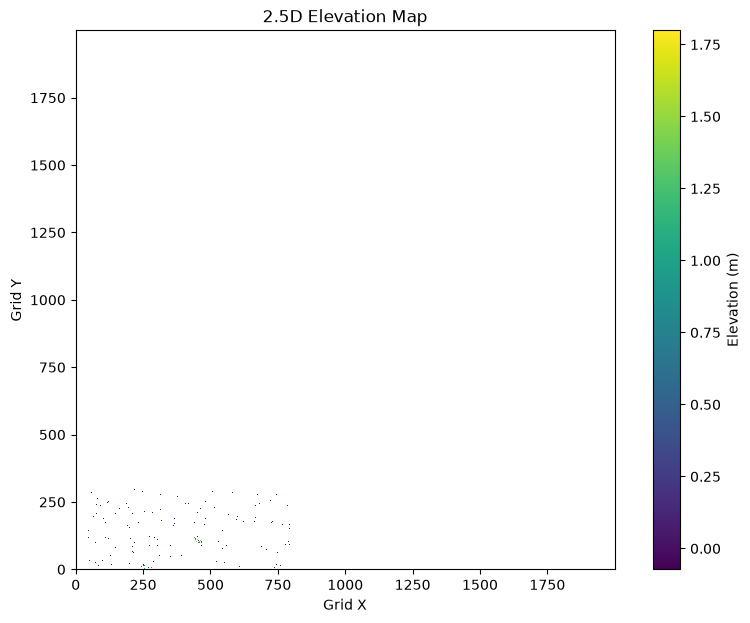

In [40]:
# 8. Visualize elevation

plt.figure(figsize=(10, 7))

masked_elevation = np.ma.masked_invalid(elevation)

plt.imshow(
    masked_elevation,
    origin="lower",
    interpolation="nearest"
)

plt.colorbar(label="Elevation (m)")
plt.title("2.5D Elevation Map")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.show()


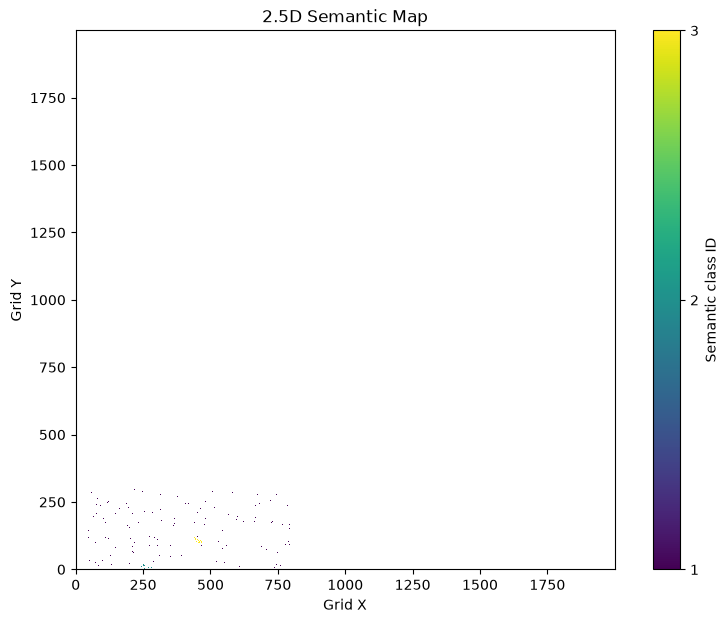

In [41]:
# 9. Visualize semantic classes

class_to_id = {
    "UNKNOWN": 0,
    "ROAD": 1,
    "VEHICLE": 2,
    "PEDESTRIAN": 3,
    "POLE": 4
}

semantic_ids = np.zeros_like(elevation, dtype=float)

for class_name, class_id in class_to_id.items():
    semantic_ids[semantic_map == class_name] = class_id

semantic_ids[np.isnan(elevation)] = np.nan

plt.figure(figsize=(10, 7))

plt.imshow(
    np.ma.masked_invalid(semantic_ids),
    origin="lower",
    interpolation="nearest"
)

plt.colorbar(
    ticks=list(class_to_id.values()),
    label="Semantic class ID"
)

plt.title("2.5D Semantic Map")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.show()


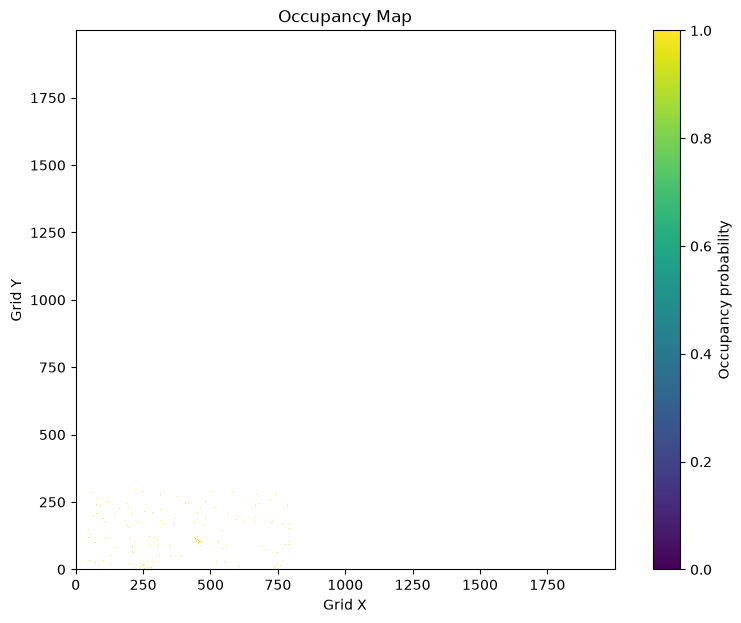

In [42]:
# 10. Visualize occupancy and dynamic probability

plt.figure(figsize=(10, 7))

plt.imshow(
    np.ma.masked_where(elevation != elevation, occupancy),
    origin="lower",
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Occupancy probability")
plt.title("Occupancy Map")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.show()


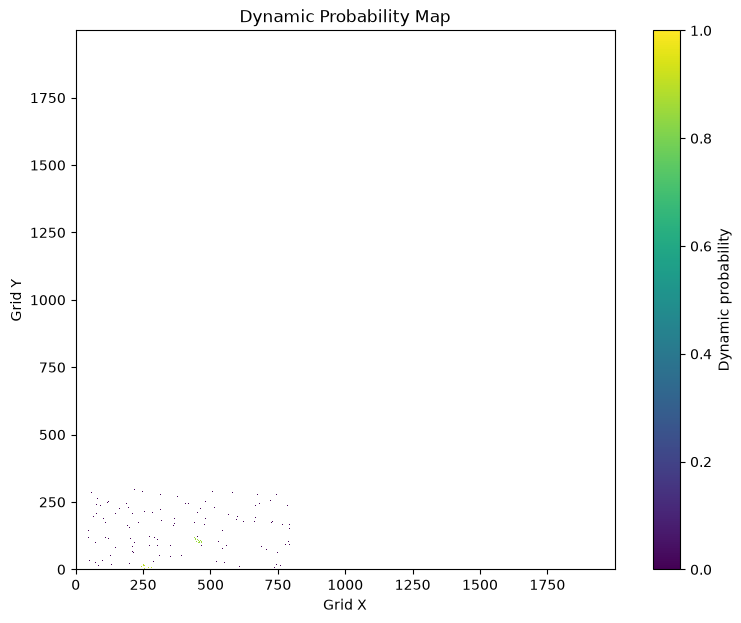

In [43]:
# 11. Dynamic probability map

plt.figure(figsize=(10, 7))

plt.imshow(
    np.ma.masked_where(elevation != elevation, dynamic_probability),
    origin="lower",
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Dynamic probability")
plt.title("Dynamic Probability Map")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.show()


In [44]:
# 12. Query a specific world coordinate

def inspect_world_position(x, y):
    gx, gy = grid.world_to_grid(x, y)

    cell = grid.get_cell(gx, gy)

    if cell is None or cell.point_count == 0:
        return {
            "cell": [gx, gy],
            "observed": False,
            "semantic": "UNKNOWN"
        }

    return {
        "cell": [gx, gy],
        "observed": True,
        "elevation": cell.elevation,
        "min_height": cell.min_height,
        "max_height": cell.max_height,
        "semantic": cell.semantic_class,
        "confidence": cell.semantic_confidence,
        "occupancy": cell.occupancy,
        "dynamic_probability": cell.dynamic_probability,
        "points": cell.point_count,
        "timestamp": cell.timestamp
    }

print(inspect_world_position(14.0, -1.0))


{'cell': [280, -20], 'observed': False, 'semantic': 'UNKNOWN'}


In [45]:
# 13. Export cells to JSON-compatible records

def grid_to_records(grid):
    records = []

    for (gx, gy), cell in grid.cells.items():
        records.append({
            "cell": [gx, gy],
            "elevation": cell.elevation,
            "min_height": cell.min_height,
            "max_height": cell.max_height,
            "semantic": cell.semantic_class,
            "confidence": cell.semantic_confidence,
            "occupancy": cell.occupancy,
            "dynamic_probability": cell.dynamic_probability,
            "points": cell.point_count,
            "timestamp": cell.timestamp
        })

    return records

records = grid_to_records(grid)

print("Number of exported cells:", len(records))
print(records[0])


Number of exported cells: 1829
{'cell': [75, 285], 'elevation': 0.0025568080633457074, 'min_height': 0.0025568080633457074, 'max_height': 0.0025568080633457074, 'semantic': 'ROAD', 'confidence': 1.0, 'occupancy': 1.0, 'dynamic_probability': 0.01, 'points': 1, 'timestamp': 1788362158.630311}


## 14. Replace the demo data with Segment 4 output

Your real pipeline should eventually look like:

```text
RAW LiDAR
   ↓
Segment 2 — Cleaning
   ↓
Segment 3 — Point classification
   ↓
Segment 4 — Objects + terrain
   ↓
THIS NOTEBOOK — Segment 5
   ↓
Fixed-resolution 2.5D semantic elevation map
   ↓
Segment 6 — Adaptive / foveated resolution
```

For the real system, replace the synthetic `points`, `labels`, `confidences`, and `dynamic_probs` with the outputs of Segment 4.

Important: this notebook intentionally uses a **uniform 5 cm grid**. The variable resolutions such as 5 cm / 10 cm / 25 cm / 50 cm should be implemented in Segment 6.


# Segment 6 — Adaptive / Foveated 2.5D Grid

Implementation of the adaptive-resolution LiDAR mapping stage.

### Resolution bands
- 0–10 m → 5 cm
- 10–30 m → 10 cm
- 30–60 m → 25 cm
- 60–100 m → 50 cm

The notebook also includes:
- Global 5 cm coordinate alignment
- Adaptive cells
- Semantic aggregation
- Object-aware refinement
- Terrain roughness refinement
- Uniform 5 cm baseline
- Cell/memory/processing benchmarks
- Visualization

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from collections import defaultdict, Counter
import time
import math


In [47]:
# Configuration

BASE_RESOLUTION = 0.05
MAX_RANGE = 100.0

DISTANCE_BANDS = [
    (10.0, 0.05),
    (30.0, 0.10),
    (60.0, 0.25),
    (100.0, 0.50),
]

DYNAMIC_THRESHOLD = 0.80
OBSTACLE_CONFIDENCE_THRESHOLD = 0.90
IMPORTANT_OBJECT_RESOLUTION = 0.10
TERRAIN_ROUGHNESS_THRESHOLD = 0.15


## 1. Distance-based Resolution Engine

In [48]:
def get_distance_resolution(distance):
    """Return the base grid resolution for a point distance."""
    if distance < 0:
        raise ValueError("Distance cannot be negative")

    for max_distance, resolution in DISTANCE_BANDS:
        if distance < max_distance:
            return resolution

    return DISTANCE_BANDS[-1][1]


test_distances = [2, 8, 15, 35, 70, 95]

for d in test_distances:
    print(f"{d:5.1f} m -> {get_distance_resolution(d) * 100:.0f} cm")


  2.0 m -> 5 cm
  8.0 m -> 5 cm
 15.0 m -> 10 cm
 35.0 m -> 25 cm
 70.0 m -> 50 cm
 95.0 m -> 50 cm


## 2. Adaptive Cell

In [49]:
@dataclass
class AdaptiveCell:
    x_index: int
    y_index: int
    resolution: float

    elevation_sum: float = 0.0
    min_height: float = np.inf
    max_height: float = -np.inf

    semantic_scores: dict = field(
        default_factory=lambda: defaultdict(float)
    )

    confidence_sum: float = 0.0
    occupied: bool = False
    dynamic_probability: float = 0.0
    point_count: int = 0
    last_updated: int = 0

    @property
    def elevation(self):
        if self.point_count == 0:
            return 0.0
        return self.elevation_sum / self.point_count

    @property
    def confidence(self):
        if self.point_count == 0:
            return 0.0
        return self.confidence_sum / self.point_count

    @property
    def semantic_class(self):
        if not self.semantic_scores:
            return "UNKNOWN"
        return max(
            self.semantic_scores,
            key=self.semantic_scores.get
        )

    def add_point(
        self,
        z,
        semantic_label="UNKNOWN",
        confidence=1.0,
        dynamic_probability=0.0,
        frame_id=0
    ):
        self.elevation_sum += z
        self.min_height = min(self.min_height, z)
        self.max_height = max(self.max_height, z)

        self.semantic_scores[semantic_label] += confidence
        self.confidence_sum += confidence

        self.dynamic_probability = max(
            self.dynamic_probability,
            dynamic_probability
        )

        self.occupied = True
        self.point_count += 1
        self.last_updated = frame_id


## 3. Global 5 cm Coordinate System

In [50]:
def world_to_base_coordinate(x, y):
    """Convert world coordinates to global 5 cm base coordinates."""
    bx = int(np.floor(x / BASE_RESOLUTION))
    by = int(np.floor(y / BASE_RESOLUTION))
    return bx, by


def get_alignment_factor(resolution):
    """Number of 5 cm base cells contained in one adaptive cell."""
    return round(resolution / BASE_RESOLUTION)


def get_adaptive_cell_index(x, y, resolution):
    """Return an aligned adaptive-cell index."""
    bx, by = world_to_base_coordinate(x, y)
    factor = get_alignment_factor(resolution)

    cell_x = bx // factor
    cell_y = by // factor

    return cell_x, cell_y


for resolution in [0.05, 0.10, 0.25, 0.50]:
    print(
        f"{resolution:.2f} m -> "
        f"{get_alignment_factor(resolution)} x "
        f"{get_alignment_factor(resolution)} base cells"
    )


0.05 m -> 1 x 1 base cells
0.10 m -> 2 x 2 base cells
0.25 m -> 5 x 5 base cells
0.50 m -> 10 x 10 base cells


## 4. Object-aware and Terrain-aware Refinement

In [51]:
def calculate_roughness(z_values):
    """Estimate terrain roughness using standard deviation of height."""
    if len(z_values) < 2:
        return 0.0
    return float(np.std(np.asarray(z_values)))


def refine_resolution(
    base_resolution,
    semantic_class="UNKNOWN",
    dynamic_probability=0.0,
    obstacle_confidence=0.0,
    terrain_roughness=0.0
):
    resolution = base_resolution

    if dynamic_probability > DYNAMIC_THRESHOLD:
        resolution = min(
            resolution,
            IMPORTANT_OBJECT_RESOLUTION
        )

    important_classes = {
        "PEDESTRIAN",
        "PERSON",
        "VEHICLE",
        "CAR",
        "BICYCLE",
        "CYCLIST"
    }

    if semantic_class.upper() in important_classes:
        resolution = min(
            resolution,
            IMPORTANT_OBJECT_RESOLUTION
        )

    if obstacle_confidence > OBSTACLE_CONFIDENCE_THRESHOLD:
        resolution = min(
            resolution,
            IMPORTANT_OBJECT_RESOLUTION
        )

    if terrain_roughness > TERRAIN_ROUGHNESS_THRESHOLD:
        resolution = min(resolution, 0.10)

    return resolution


def final_resolution_engine(
    x,
    y,
    semantic_class="UNKNOWN",
    dynamic_probability=0.0,
    obstacle_confidence=0.0,
    terrain_roughness=0.0
):
    distance = np.sqrt(x*x + y*y)

    base_resolution = get_distance_resolution(distance)

    return refine_resolution(
        base_resolution,
        semantic_class=semantic_class,
        dynamic_probability=dynamic_probability,
        obstacle_confidence=obstacle_confidence,
        terrain_roughness=terrain_roughness
    )


## 5. Generate Synthetic LiDAR Data

In [52]:
def generate_synthetic_lidar(
    num_points=200000,
    max_range=100
):
    rng = np.random.default_rng(42)

    x = rng.uniform(-max_range, max_range, num_points)
    y = rng.uniform(-max_range, max_range, num_points)

    distance = np.sqrt(x*x + y*y)
    mask = distance <= max_range

    x = x[mask]
    y = y[mask]

    # Ground
    z = rng.normal(0, 0.03, len(x))

    # Rough terrain patch
    terrain_mask = (
        (x > 15) &
        (x < 30) &
        (y > -10) &
        (y < 10)
    )

    z[terrain_mask] += (
        0.3 * np.sin(x[terrain_mask])
    )

    # Semantic labels
    labels = np.full(
        len(x),
        "ROAD",
        dtype=object
    )

    # Vehicle
    vehicle_mask = (
        (x > 20) &
        (x < 25) &
        (y > 5) &
        (y < 9)
    )

    labels[vehicle_mask] = "VEHICLE"

    # Pedestrian
    pedestrian_mask = (
        (x > 45) &
        (x < 46) &
        (y > 10) &
        (y < 11)
    )

    labels[pedestrian_mask] = "PEDESTRIAN"

    confidence = rng.uniform(
        0.7,
        1.0,
        len(x)
    )

    dynamic_probability = np.zeros(len(x))

    dynamic_probability[
        labels == "VEHICLE"
    ] = 0.90

    dynamic_probability[
        labels == "PEDESTRIAN"
    ] = 0.95

    return (
        x,
        y,
        z,
        labels,
        confidence,
        dynamic_probability
    )


x, y, z, labels, confidence, dynamic_probability = (
    generate_synthetic_lidar()
)

print("LiDAR points:", len(x))


LiDAR points: 157086


## 6. Visualize Raw LiDAR

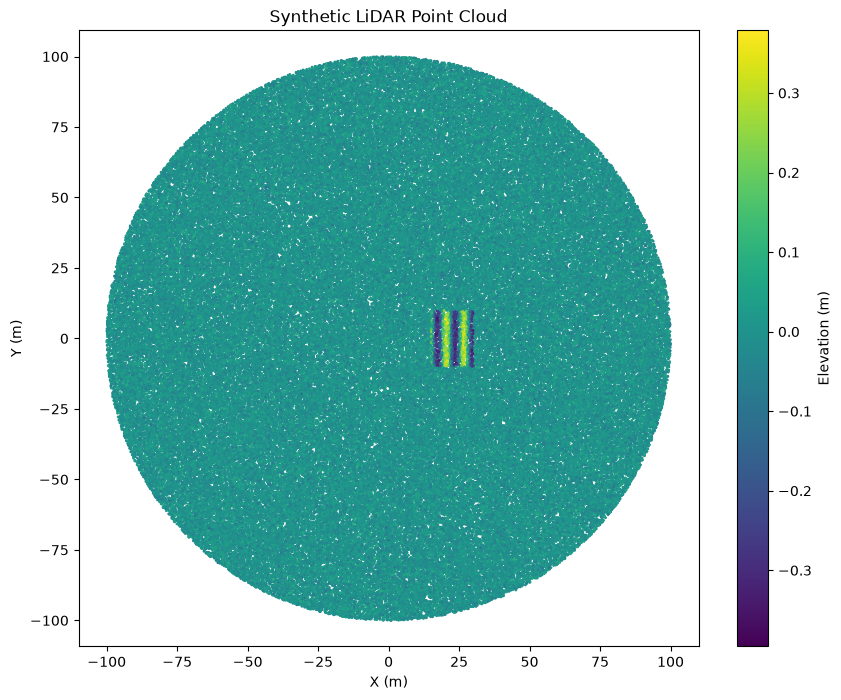

In [53]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    x,
    y,
    c=z,
    s=1
)

plt.colorbar(scatter, label="Elevation (m)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Synthetic LiDAR Point Cloud")
plt.axis("equal")
plt.show()


## 7. Build Adaptive Grid

In [54]:
def build_adaptive_grid(
    x,
    y,
    z,
    labels,
    confidence,
    dynamic_probability,
    frame_id=0
):
    grid = {}

    for i in range(len(x)):
        px = x[i]
        py = y[i]
        pz = z[i]

        distance = np.sqrt(px*px + py*py)

        if distance > MAX_RANGE:
            continue

        resolution = get_distance_resolution(distance)

        cx, cy = get_adaptive_cell_index(
            px,
            py,
            resolution
        )

        key = (cx, cy, resolution)

        if key not in grid:
            grid[key] = AdaptiveCell(
                x_index=cx,
                y_index=cy,
                resolution=resolution
            )

        grid[key].add_point(
            z=pz,
            semantic_label=labels[i],
            confidence=confidence[i],
            dynamic_probability=dynamic_probability[i],
            frame_id=frame_id
        )

    return grid


start = time.perf_counter()

adaptive_grid = build_adaptive_grid(
    x,
    y,
    z,
    labels,
    confidence,
    dynamic_probability
)

adaptive_time = time.perf_counter() - start

print("Adaptive cells:", len(adaptive_grid))
print("Processing time:", adaptive_time, "seconds")


Adaptive cells: 107960
Processing time: 0.666071199986618 seconds


## 8. Resolution Distribution

In [55]:
resolution_counts = Counter(
    cell.resolution
    for cell in adaptive_grid.values()
)

print("Resolution distribution")
print("-----------------------")

for resolution in sorted(resolution_counts):
    count = resolution_counts[resolution]
    print(
        f"{resolution * 100:5.0f} cm -> "
        f"{count:,} cells"
    )

print("\nTotal cells:", len(adaptive_grid))


Resolution distribution
-----------------------
    5 cm -> 1,567 cells
   10 cm -> 12,232 cells
   25 cm -> 36,495 cells
   50 cm -> 57,666 cells

Total cells: 107960


## 9. Convert Adaptive Grid to DataFrame

In [56]:
def grid_to_dataframe(grid):
    rows = []

    for cell in grid.values():
        rows.append({
            "x_index": cell.x_index,
            "y_index": cell.y_index,
            "resolution": cell.resolution,

            "x": cell.x_index * cell.resolution,
            "y": cell.y_index * cell.resolution,

            "elevation": cell.elevation,
            "min_height": cell.min_height,
            "max_height": cell.max_height,

            "semantic_class": cell.semantic_class,
            "confidence": cell.confidence,

            "occupancy": int(cell.occupied),
            "dynamic_probability": cell.dynamic_probability,

            "point_count": cell.point_count,
            "last_updated": cell.last_updated
        })

    return pd.DataFrame(rows)


adaptive_df = grid_to_dataframe(adaptive_grid)

adaptive_df.head()


,x_index,y_index,resolution,x,y,elevation,min_height,max_height,semantic_class,confidence,occupancy,dynamic_probability,point_count,last_updated
0,219,-78,0.25,54.75,-19.5,0.008260,0.008260,0.008260,ROAD,0.878253,1,0.0,1,0
1,-123,-217,0.10,-12.30,-21.7,-0.004752,-0.004752,-0.004752,ROAD,0.786622,1,0.0,1,0
2,157,62,0.25,39.25,15.5,0.014268,0.014268,0.014268,ROAD,0.994089,1,0.0,1,0
3,-163,103,0.50,-81.50,51.5,0.026107,0.011644,0.040570,ROAD,0.807288,1,0.0,2,0
4,190,-44,0.50,95.00,-22.0,0.008067,-0.007788,0.019703,ROAD,0.842373,1,0.0,5,0


## 10. Visualize Adaptive Resolution

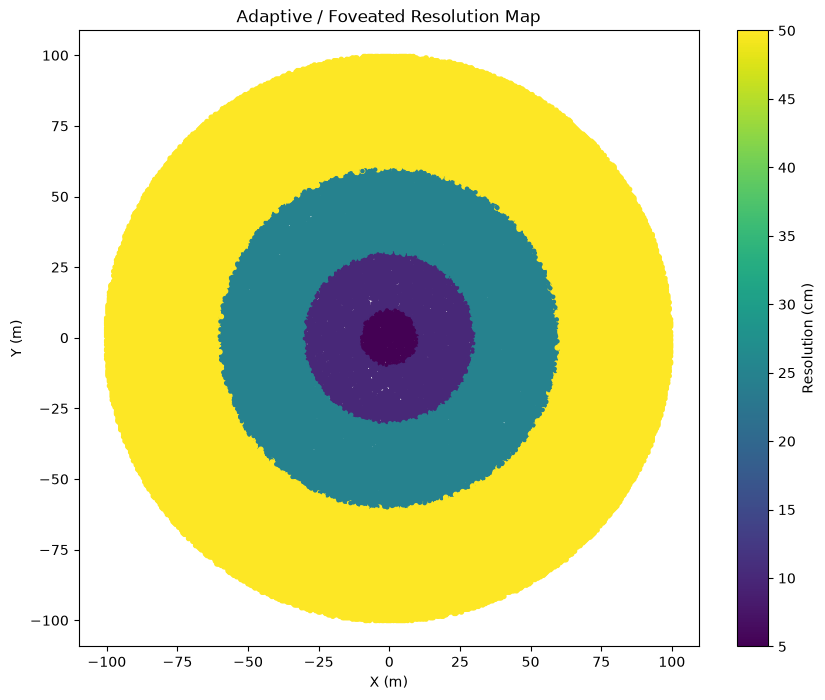

In [57]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    adaptive_df["x"],
    adaptive_df["y"],
    c=adaptive_df["resolution"] * 100,
    s=np.maximum(adaptive_df["resolution"] * 20, 3)
)

plt.colorbar(
    scatter,
    label="Resolution (cm)"
)

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Adaptive / Foveated Resolution Map")
plt.axis("equal")
plt.show()


## 11. Visualize Semantic Map

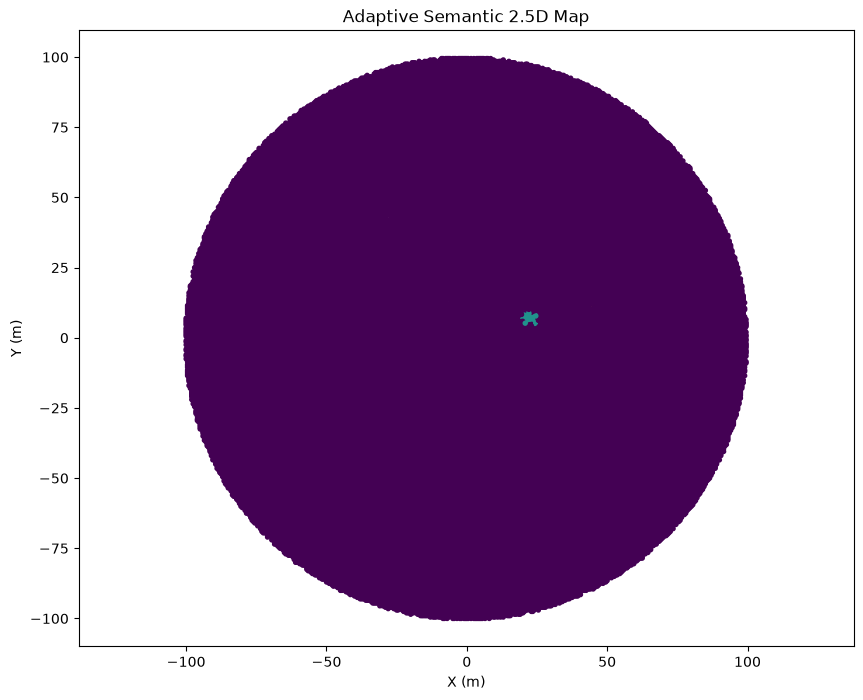

Semantic classes:
{'ROAD': 0, 'VEHICLE': 1, 'PEDESTRIAN': 2}


In [58]:
semantic_map = {
    label: i
    for i, label in enumerate(
        adaptive_df["semantic_class"].unique()
    )
}

semantic_values = (
    adaptive_df["semantic_class"]
    .map(semantic_map)
)

plt.figure(figsize=(10, 8))

plt.scatter(
    adaptive_df["x"],
    adaptive_df["y"],
    c=semantic_values,
    s=8
)

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Adaptive Semantic 2.5D Map")
plt.axis("equal")
plt.show()

print("Semantic classes:")
print(semantic_map)


## 12. Uniform 5 cm Baseline

In [59]:
def build_uniform_grid(
    x,
    y,
    z,
    resolution=0.05
):
    grid = {}

    for i in range(len(x)):
        distance = np.sqrt(x[i]**2 + y[i]**2)

        if distance > MAX_RANGE:
            continue

        gx = int(np.floor(x[i] / resolution))
        gy = int(np.floor(y[i] / resolution))

        key = (gx, gy)

        if key not in grid:
            grid[key] = {
                "elevation_sum": 0.0,
                "count": 0
            }

        grid[key]["elevation_sum"] += z[i]
        grid[key]["count"] += 1

    return grid


start = time.perf_counter()

uniform_grid = build_uniform_grid(
    x,
    y,
    z,
    resolution=0.05
)

uniform_time = time.perf_counter() - start

print("Uniform 5 cm cells:", len(uniform_grid))
print("Processing time:", uniform_time, "seconds")


Uniform 5 cm cells: 156124
Processing time: 0.20369679998839274 seconds


## 13. Memory and Cell Reduction Benchmark

In [60]:
def estimate_memory_bytes(num_cells):
    # Approximate feature-storage estimate.
    # This excludes Python object/dictionary overhead.
    BYTES_PER_CELL = 25
    return num_cells * BYTES_PER_CELL


adaptive_memory = estimate_memory_bytes(len(adaptive_grid))
uniform_memory = estimate_memory_bytes(len(uniform_grid))

cell_reduction = (
    1 -
    len(adaptive_grid) / len(uniform_grid)
) * 100

memory_reduction = (
    1 -
    adaptive_memory / uniform_memory
) * 100

print(
    f"Cell reduction: {cell_reduction:.2f}%"
)

print(
    f"Estimated memory reduction: "
    f"{memory_reduction:.2f}%"
)


Cell reduction: 30.85%
Estimated memory reduction: 30.85%


## 14. Benchmark Summary

In [61]:
benchmark = pd.DataFrame({
    "Metric": [
        "Number of cells",
        "Processing time (s)",
        "Estimated memory (MB)"
    ],

    "Uniform 5cm": [
        len(uniform_grid),
        uniform_time,
        uniform_memory / (1024**2)
    ],

    "Adaptive": [
        len(adaptive_grid),
        adaptive_time,
        adaptive_memory / (1024**2)
    ]
})

benchmark


,Metric,Uniform 5cm,Adaptive
0,Number of cells,156124.000000,107960.000000
1,Processing time (s),0.203697,0.666071
2,Estimated memory (MB),3.722286,2.573967


## 15. Far-away Object Refinement Test

In [62]:
def inspect_far_objects(
    x,
    y,
    labels,
    dynamic_probability
):
    results = []

    for i in range(len(x)):
        distance = np.sqrt(x[i]**2 + y[i]**2)

        if distance < 30:
            continue

        base_resolution = get_distance_resolution(distance)

        final_resolution = refine_resolution(
            base_resolution,
            semantic_class=labels[i],
            dynamic_probability=dynamic_probability[i]
        )

        if final_resolution < base_resolution:
            results.append({
                "distance": distance,
                "object": labels[i],
                "normal_resolution": base_resolution,
                "refined_resolution": final_resolution
            })

    return pd.DataFrame(results)


far_objects = inspect_far_objects(
    x,
    y,
    labels,
    dynamic_probability
)

far_objects.head(20)


,distance,object,normal_resolution,refined_resolution
0,46.240733,PEDESTRIAN,0.25,0.1
1,46.550589,PEDESTRIAN,0.25,0.1
2,46.429430,PEDESTRIAN,0.25,0.1
3,47.075335,PEDESTRIAN,0.25,0.1
4,47.205789,PEDESTRIAN,0.25,0.1
5,46.887552,PEDESTRIAN,0.25,0.1


## 16. Final Resolution Decision Engine

The final design combines:

**Distance + Object Importance + Terrain Complexity + Confidence → Resolution → Adaptive Map**

In [63]:
# Example decisions

examples = [
    {
        "name": "Near road",
        "x": 5,
        "y": 2,
        "semantic": "ROAD",
        "dynamic": 0.0,
        "confidence": 0.95,
        "roughness": 0.02
    },
    {
        "name": "Far road",
        "x": 70,
        "y": 0,
        "semantic": "ROAD",
        "dynamic": 0.0,
        "confidence": 0.95,
        "roughness": 0.02
    },
    {
        "name": "Far pedestrian",
        "x": 50,
        "y": 10,
        "semantic": "PEDESTRIAN",
        "dynamic": 0.95,
        "confidence": 0.95,
        "roughness": 0.02
    },
    {
        "name": "Rough terrain",
        "x": 50,
        "y": 10,
        "semantic": "ROAD",
        "dynamic": 0.0,
        "confidence": 0.95,
        "roughness": 0.30
    }
]

for item in examples:
    resolution = final_resolution_engine(
        item["x"],
        item["y"],
        semantic_class=item["semantic"],
        dynamic_probability=item["dynamic"],
        obstacle_confidence=item["confidence"],
        terrain_roughness=item["roughness"]
    )

    print(
        f'{item["name"]:20s} -> '
        f'{resolution * 100:.0f} cm'
    )


Near road            -> 5 cm
Far road             -> 10 cm
Far pedestrian       -> 10 cm
Rough terrain        -> 10 cm


## 17. Save the Adaptive 2.5D Map

In [64]:
output_file = "adaptive_2_5D_map.csv"

adaptive_df.to_csv(
    output_file,
    index=False
)

print(f"Saved: {output_file}")


Saved: adaptive_2_5D_map.csv


## Segment 6 Completion Check

The notebook should now produce:

1. A distance-adaptive 2.5D grid
2. Aligned 5 cm / 10 cm / 25 cm / 50 cm spatial levels
3. Semantic and elevation information per cell
4. Object-aware refinement
5. Terrain-aware refinement
6. Uniform-vs-adaptive benchmark
7. Resolution distribution
8. CSV output for the next segment

### Next integration point

The adaptive grid can now be connected to **Segment 7**, where the vehicle moves and the map is incrementally updated instead of rebuilding the entire map every frame.

# Segment 7 — Real-Time Optimization, Visualization & Benchmarking

This notebook implements the **Segment 7 prototype** for the Adaptive Variable Resolution 2.5D LiDAR Mapping system.

Pipeline:

**LiDAR → Preprocessing → Adaptive Downsampling → 2.5D Map → Static/Dynamic Layers → Profiling → Visualization → Benchmarking**

> The notebook uses synthetic LiDAR data by default so the complete pipeline can be tested before connecting a real `.bin` dataset.


In [65]:
# Install dependencies
# Run this cell once if the packages are not already installed.

!pip install numpy matplotlib open3d psutil pandas


In [66]:
# Imports

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import pandas as pd
import psutil
import time
from collections import defaultdict

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Generate / Load LiDAR Data

For initial testing, synthetic LiDAR frames are generated.

Later, replace this with the real LiDAR dataset loader.


In [67]:
def generate_lidar_frame(num_points=100000, max_range=100):
    """
    Generate a synthetic LiDAR point cloud.

    Returns:
        points: Nx3 array containing [x, y, z].
    """

    angles = np.random.uniform(0, 2 * np.pi, num_points)
    distances = np.random.uniform(2, max_range, num_points)

    x = distances * np.cos(angles)
    y = distances * np.sin(angles)

    # Simulated ground
    z = np.random.normal(0, 0.05, num_points)

    # Simulated obstacle
    obstacle_mask = (
        (x > 10) & (x < 15) &
        (y > 2) & (y < 6)
    )

    z[obstacle_mask] += np.random.uniform(
        0.5, 2.0, obstacle_mask.sum()
    )

    points = np.column_stack((x, y, z))

    return points


In [68]:
def load_kitti_bin(filename):
    """
    Load a KITTI-style LiDAR .bin file.

    Expected format:
        x, y, z, intensity
    """

    data = np.fromfile(filename, dtype=np.float32)

    points = data.reshape(-1, 4)

    xyz = points[:, :3]
    intensity = points[:, 3]

    return xyz, intensity


# Example:
# points, intensity = load_kitti_bin("data/000000.bin")


## 2. Preprocessing

Remove invalid points and points outside the mapping range.


In [69]:
def preprocess_points(points, max_range=100):
    """Remove invalid and out-of-range points."""

    # Remove NaN / Inf
    mask = np.isfinite(points).all(axis=1)
    points = points[mask]

    # Horizontal distance from vehicle
    distance = np.sqrt(
        points[:, 0] ** 2 +
        points[:, 1] ** 2
    )

    # Keep points within range
    mask = distance <= max_range

    return points[mask]


## 3. Adaptive Voxel Downsampling

Resolution changes according to distance:

| Distance | Resolution |
|---|---:|
| 0–10 m | 5 cm |
| 10–30 m | 10 cm |
| 30–60 m | 25 cm |
| 60–100 m | 50 cm |

This reduces computation while keeping higher detail close to the vehicle.


In [70]:
def adaptive_voxel_downsample(points):
    """
    Adaptive resolution:

    0-10m   -> 5cm
    10-30m  -> 10cm
    30-60m  -> 25cm
    60-100m -> 50cm
    """

    if len(points) == 0:
        return np.empty((0, 3))

    distance = np.sqrt(
        points[:, 0] ** 2 +
        points[:, 1] ** 2
    )

    resolution = np.zeros(len(points))

    resolution[distance < 10] = 0.05
    resolution[(distance >= 10) & (distance < 30)] = 0.10
    resolution[(distance >= 30) & (distance < 60)] = 0.25
    resolution[distance >= 60] = 0.50

    output = []

    for voxel_size in [0.05, 0.10, 0.25, 0.50]:

        mask = resolution == voxel_size

        if not np.any(mask):
            continue

        pts = points[mask]

        voxel_indices = np.floor(
            pts / voxel_size
        ).astype(np.int32)

        _, unique_indices = np.unique(
            voxel_indices,
            axis=0,
            return_index=True
        )

        output.append(pts[unique_indices])

    if not output:
        return np.empty((0, 3))

    return np.vstack(output)


## 4. Adaptive 2.5D Map

Each `(x, y)` cell stores:

- maximum observed height
- occupancy
- semantic label placeholder

The semantic layer can later be populated by Segment 3/4 outputs.


In [71]:
class Adaptive25DMap:

    def __init__(self, size=100, resolution=0.5):

        self.size = size
        self.resolution = resolution

        self.cells = int(size / resolution)

        self.height = np.full(
            (self.cells, self.cells),
            np.nan
        )

        self.occupancy = np.zeros(
            (self.cells, self.cells),
            dtype=np.uint8
        )

        self.semantic = np.zeros(
            (self.cells, self.cells),
            dtype=np.int32
        )

    def update(self, points):

        half = self.size / 2

        for x, y, z in points:

            ix = int((x + half) / self.resolution)
            iy = int((y + half) / self.resolution)

            if (
                ix < 0 or
                iy < 0 or
                ix >= self.cells or
                iy >= self.cells
            ):
                continue

            if np.isnan(self.height[ix, iy]):
                self.height[ix, iy] = z
            else:
                self.height[ix, iy] = max(
                    self.height[ix, iy],
                    z
                )

            self.occupancy[ix, iy] = 1


## 5. Static and Dynamic Layers

Static information changes slowly, while dynamic information such as vehicles and pedestrians changes every frame.


In [72]:
class StaticDynamicMap:

    def __init__(self, size=100):

        self.static_map = Adaptive25DMap(
            size=size,
            resolution=0.5
        )

        self.dynamic_map = Adaptive25DMap(
            size=size,
            resolution=0.5
        )

    def update_static(self, points):
        self.static_map.update(points)

    def update_dynamic(self, points):
        self.dynamic_map.update(points)


## 6. Performance Profiler

Measures:

- preprocessing time
- adaptive downsampling time
- mapping time
- total latency
- FPS
- memory usage


In [73]:
class Profiler:

    def __init__(self):
        self.results = []

    def start(self):
        return time.perf_counter()

    def stop(self, start):
        return (time.perf_counter() - start) * 1000

    def record(
        self,
        frame_id,
        preprocessing,
        downsampling,
        mapping
    ):

        total = (
            preprocessing +
            downsampling +
            mapping
        )

        fps = 1000 / total if total > 0 else 0

        memory = (
            psutil.Process().memory_info().rss
            / (1024 * 1024)
        )

        self.results.append({
            "frame": frame_id,
            "preprocessing_ms": preprocessing,
            "downsampling_ms": downsampling,
            "mapping_ms": mapping,
            "total_ms": total,
            "FPS": fps,
            "memory_MB": memory
        })

    def dataframe(self):
        return pd.DataFrame(self.results)


## 7. Complete Single-Frame Pipeline

In [74]:
def process_frame(
    points,
    map_system,
    profiler,
    frame_id
):

    # -------------------------
    # PREPROCESSING
    # -------------------------

    start = profiler.start()

    clean_points = preprocess_points(points)

    preprocessing_time = profiler.stop(start)

    # -------------------------
    # ADAPTIVE DOWNSAMPLING
    # -------------------------

    start = profiler.start()

    adaptive_points = adaptive_voxel_downsample(
        clean_points
    )

    downsampling_time = profiler.stop(start)

    # -------------------------
    # MAP UPDATE
    # -------------------------

    start = profiler.start()

    map_system.update_static(
        adaptive_points
    )

    mapping_time = profiler.stop(start)

    # -------------------------
    # RECORD PERFORMANCE
    # -------------------------

    profiler.record(
        frame_id,
        preprocessing_time,
        downsampling_time,
        mapping_time
    )

    return adaptive_points


## 8. Run the Pipeline

The following cell processes 10 synthetic LiDAR frames.


In [75]:
map_system = StaticDynamicMap(size=100)
profiler = Profiler()

for frame_id in range(10):

    raw_points = generate_lidar_frame(
        num_points=100000
    )

    processed_points = process_frame(
        raw_points,
        map_system,
        profiler,
        frame_id
    )

    print(
        f"Frame {frame_id:02d}: "
        f"{len(raw_points):,} → "
        f"{len(processed_points):,} points"
    )


Frame 00: 100,000 → 93,119 points
Frame 01: 100,000 → 92,943 points
Frame 02: 100,000 → 92,880 points
Frame 03: 100,000 → 93,032 points
Frame 04: 100,000 → 92,922 points
Frame 05: 100,000 → 92,812 points
Frame 06: 100,000 → 92,930 points
Frame 07: 100,000 → 92,791 points
Frame 08: 100,000 → 93,003 points
Frame 09: 100,000 → 92,918 points


## 9. Performance Results

In [76]:
results = profiler.dataframe()

display(results)


,frame,preprocessing_ms,downsampling_ms,mapping_ms,total_ms,FPS,memory_MB
0,0,3.4820,54.0789,102.3474,159.9083,6.253584,942.414062
1,1,3.4757,55.8812,107.6240,166.9809,5.988709,944.546875
2,2,3.4652,54.0184,108.1900,165.6736,6.035965,944.546875
3,3,3.3894,54.0041,106.6552,164.0487,6.095751,944.550781
4,4,3.5072,58.6370,106.1443,168.2885,5.942177,944.550781
5,5,3.5719,54.9452,106.2299,164.7470,6.069913,944.542969
6,6,3.5702,57.4335,106.2914,167.2951,5.977461,944.542969
7,7,4.2284,54.6276,104.7476,163.6036,6.112335,944.542969
8,8,3.3492,54.2156,111.7371,169.3019,5.906608,944.542969
9,9,3.3758,54.0020,109.3700,166.7478,5.997081,944.546875


In [77]:
print("Average latency:",
      results["total_ms"].mean(), "ms")

print("Minimum latency:",
      results["total_ms"].min(), "ms")

print("Maximum latency:",
      results["total_ms"].max(), "ms")

print("P95 latency:",
      np.percentile(results["total_ms"], 95), "ms")

print("Average FPS:",
      results["FPS"].mean())


Average latency: 165.6595400068909 ms
Minimum latency: 159.90830003283918 ms
Maximum latency: 169.30190002312884 ms
P95 latency: 168.84586998203304 ms
Average FPS: 6.037958363357799


## 10. FPS Visualization

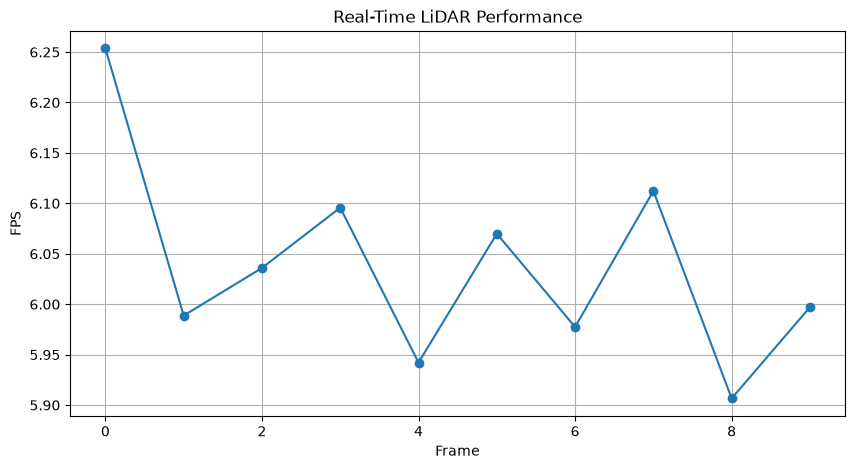

In [78]:
plt.figure(figsize=(10, 5))

plt.plot(
    results["frame"],
    results["FPS"],
    marker="o"
)

plt.xlabel("Frame")
plt.ylabel("FPS")
plt.title("Real-Time LiDAR Performance")
plt.grid()

plt.show()


## 11. Point Cloud Visualization

Open3D is used for the initial 3D visualization.


In [79]:
def visualize_pointcloud(points):

    cloud = o3d.geometry.PointCloud()

    cloud.points = o3d.utility.Vector3dVector(
        points
    )

    o3d.visualization.draw_geometries(
        [cloud],
        window_name="Adaptive LiDAR"
    )


# Example:
# visualize_pointcloud(processed_points)


## 12. Uniform vs Adaptive Cell Count

The proposed system should eventually be benchmarked against a uniform-resolution map.


In [80]:
def calculate_uniform_cells(
    size=100,
    resolution=0.05
):

    cells_per_axis = int(size / resolution)

    return cells_per_axis ** 2


def calculate_adaptive_cells(points):

    if len(points) == 0:
        return 0

    distance = np.sqrt(
        points[:, 0] ** 2 +
        points[:, 1] ** 2
    )

    cells = 0

    ranges = [
        (0, 10, 0.05),
        (10, 30, 0.10),
        (30, 60, 0.25),
        (60, 100, 0.50)
    ]

    for rmin, rmax, resolution in ranges:

        mask = (
            (distance >= rmin) &
            (distance < rmax)
        )

        if np.any(mask):

            pts = points[mask]

            voxels = np.floor(
                pts / resolution
            ).astype(np.int32)

            cells += len(
                np.unique(
                    voxels,
                    axis=0
                )
            )

    return cells


In [81]:
raw = generate_lidar_frame(
    num_points=100000
)

adaptive = adaptive_voxel_downsample(raw)

uniform_cells = calculate_uniform_cells()

adaptive_cells = calculate_adaptive_cells(raw)

reduction = (
    1 -
    adaptive_cells / uniform_cells
) * 100

print("Uniform cells:", f"{uniform_cells:,}")
print("Adaptive cells:", f"{adaptive_cells:,}")
print(f"Cell reduction: {reduction:.2f}%")


Uniform cells: 4,000,000
Adaptive cells: 92,902
Cell reduction: 97.68%


## 13. Final Benchmark Summary

This produces a compact benchmark table for the current prototype.


In [82]:
summary = pd.DataFrame({
    "Metric": [
        "Average latency (ms)",
        "P95 latency (ms)",
        "Average FPS",
        "Peak memory (MB)",
        "Raw points",
        "Adaptive points",
        "Uniform cells",
        "Adaptive cells",
        "Cell reduction (%)"
    ],

    "Value": [
        results["total_ms"].mean(),
        np.percentile(results["total_ms"], 95),
        results["FPS"].mean(),
        results["memory_MB"].max(),
        len(raw),
        len(adaptive),
        uniform_cells,
        adaptive_cells,
        reduction
    ]
})

display(summary)


,Metric,Value
0,Average latency (ms),1.656595e+02
1,P95 latency (ms),1.688459e+02
2,Average FPS,6.037958e+00
3,Peak memory (MB),9.445508e+02
4,Raw points,1.000000e+05
5,Adaptive points,9.290200e+04
6,Uniform cells,4.000000e+06
7,Adaptive cells,9.290200e+04
8,Cell reduction (%),9.767745e+01


# Segment 7 Completion Checklist

The prototype now contains:

- [x] LiDAR input
- [x] Preprocessing
- [x] Adaptive voxel downsampling
- [x] 2.5D map
- [x] Static/dynamic map structure
- [x] Frame-by-frame pipeline
- [x] Latency measurement
- [x] FPS measurement
- [x] Memory measurement
- [x] P95 latency
- [x] Open3D visualization function
- [x] Uniform vs adaptive benchmark

### Next integration step

Connect:

**Segment 3 → Semantic Segmentation**

and

**Segment 4 → Object Detection/Tracking**

before using the system as the complete Adaptive 2.5D LiDAR pipeline.


# Segment 8 — LiDAR Validation & SIH Demo

This notebook implements the validation plan from the supplied file: uniform 5 cm vs adaptive 5–50 cm mapping, latency/FPS, memory, cell count, distance-wise analysis, elevation MAE/RMSE, object-preservation tests, visualization, and CSV output. fileciteturn0file0L49-L84

The supplied file is a roadmap rather than source code, so the implementation below is a practical reference implementation.

In [83]:
import time
import tracemalloc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def load_lidar(path):
    path = Path(path)
    if path.suffix.lower() == ".bin":
        raw = np.fromfile(path, dtype=np.float32)
        if raw.size % 4 != 0:
            raise ValueError("BIN file must contain x,y,z,intensity values.")
        return raw.reshape(-1, 4)
    if path.suffix.lower() == ".npy":
        return np.load(path).astype(np.float32)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path).values.astype(np.float32)
    raise ValueError("Use .bin, .npy or .csv")

def make_demo_lidar(n=120000, seed=42):
    rng = np.random.default_rng(seed)
    x = rng.uniform(2, 100, n)
    y = rng.uniform(-25, 25, n)
    z = rng.normal(0, 0.025, n)
    road = np.column_stack([x, y, z])

    objs = []
    for cx, cy, w, d, h in [(18,4,2,4,1.5),(38,-7,1.2,1.2,1.7),
                            (62,9,2.2,4.5,1.6),(78,-3,.8,.8,1.8)]:
        m = 1500
        ox = rng.uniform(cx-w/2, cx+w/2, m)
        oy = rng.uniform(cy-d/2, cy+d/2, m)
        oz = rng.uniform(.05, h, m)
        objs.append(np.column_stack([ox, oy, oz]))
    return np.vstack([road] + objs).astype(np.float32)

# Put your real file here, e.g. "data/000123.bin"
LIDAR_FILE = None

lidar = load_lidar(LIDAR_FILE) if LIDAR_FILE and Path(LIDAR_FILE).exists() else make_demo_lidar()
xyz = lidar[:, :3]
print("LiDAR points:", len(xyz))


LiDAR points: 126000


## Uniform 5 cm 2.5D map

In [84]:
def build_uniform_25d(points, resolution=0.05):
    xyz = points[:, :3]
    xmin, ymin = xyz[:,0].min(), xyz[:,1].min()

    ix = np.floor((xyz[:,0] - xmin) / resolution).astype(np.int32)
    iy = np.floor((xyz[:,1] - ymin) / resolution).astype(np.int32)

    keys = np.column_stack((ix, iy))
    unique_keys, inverse = np.unique(keys, axis=0, return_inverse=True)

    z = xyz[:,2]
    zmin = np.full(len(unique_keys), np.inf, dtype=np.float32)
    zmax = np.full(len(unique_keys), -np.inf, dtype=np.float32)
    count = np.bincount(inverse)

    np.minimum.at(zmin, inverse, z)
    np.maximum.at(zmax, inverse, z)

    grid = {
        tuple(k): (float(zmin[i]), float(zmax[i]), int(count[i]))
        for i, k in enumerate(unique_keys)
    }
    return grid


## Adaptive 5–50 cm map

The distance policy follows the supplied plan: 5 cm near the vehicle, then 10 cm, 25 cm and 50 cm farther away. Important-object regions are refined to at least 10 cm. fileciteturn0file0L298-L334

In [85]:
def adaptive_resolution(x, y, object_mask=None):
    d = np.sqrt(x*x + y*y)

    r = np.where(d <= 10, 0.05,
         np.where(d <= 30, 0.10,
         np.where(d <= 60, 0.25, 0.50)))

    if object_mask is not None:
        r = np.where(object_mask, np.minimum(r, 0.10), r)

    return r

def build_adaptive_25d(points, object_mask=None):
    xyz = points[:, :3]
    x, y, z = xyz.T
    r = adaptive_resolution(x, y, object_mask)

    xmin, ymin = x.min(), y.min()
    ix = np.floor((x-xmin)/r).astype(np.int64)
    iy = np.floor((y-ymin)/r).astype(np.int64)

    cells = {}
    for a, b, rr, zz in zip(ix, iy, r, z):
        key = (int(a), int(b), float(rr))
        if key not in cells:
            cells[key] = [float(zz), float(zz), 1]
        else:
            cells[key][0] = min(cells[key][0], float(zz))
            cells[key][1] = max(cells[key][1], float(zz))
            cells[key][2] += 1

    return cells, r


In [86]:
def benchmark(method, points, object_mask=None):
    tracemalloc.start()
    t0 = time.perf_counter()

    if method == "Uniform 5cm":
        grid = build_uniform_25d(points)
        resolutions = None
    else:
        grid, resolutions = build_adaptive_25d(points, object_mask)

    latency = (time.perf_counter() - t0) * 1000
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "method": method,
        "cells": len(grid),
        "latency_ms": latency,
        "fps": 1000 / latency if latency > 0 else np.inf,
        "memory_mb": peak / (1024**2),
        "grid": grid,
        "resolutions": resolutions
    }

# Replace this demo mask with your real Segment 3/4 detector output.
object_mask = (
    ((xyz[:,0] > 16) & (xyz[:,0] < 20) & (xyz[:,1] > 2) & (xyz[:,1] < 6)) |
    ((xyz[:,0] > 37) & (xyz[:,0] < 39) & (xyz[:,1] > -8) & (xyz[:,1] < -6))
)

uniform = benchmark("Uniform 5cm", lidar)
adaptive = benchmark("Adaptive 5-50cm", lidar, object_mask)

results = pd.DataFrame([
    {k:v for k,v in uniform.items() if k not in ["grid","resolutions"]},
    {k:v for k,v in adaptive.items() if k not in ["grid","resolutions"]}
])
results


,method,cells,latency_ms,fps,memory_mb
0,Uniform 5cm,119459,999.3811,1.000619,35.157603
1,Adaptive 5-50cm,55487,1433.8408,0.697427,17.289493


In [87]:
def percent_reduction(old, new):
    return (old-new)/old*100 if old else 0

print("Cell reduction:   %.2f%%" % percent_reduction(uniform["cells"], adaptive["cells"]))
print("Memory reduction: %.2f%%" % percent_reduction(uniform["memory_mb"], adaptive["memory_mb"]))
print("Latency reduction: %.2f%%" % percent_reduction(uniform["latency_ms"], adaptive["latency_ms"]))
print("Uniform FPS:      %.2f" % uniform["fps"])
print("Adaptive FPS:     %.2f" % adaptive["fps"])


Cell reduction:   53.55%
Memory reduction: 50.82%
Latency reduction: -43.47%
Uniform FPS:      1.00
Adaptive FPS:     0.70


## Distance-wise analysis

The supplied validation plan uses 0–10 m, 10–30 m, 30–60 m and 60–100 m. fileciteturn0file0L145-L171

In [88]:
distance = np.sqrt(xyz[:,0]**2 + xyz[:,1]**2)
labels = np.select(
    [distance <= 10, distance <= 30, distance <= 60, distance <= 100],
    ["0-10m","10-30m","30-60m","60-100m"],
    default=">100m"
)

rows = []
for label in ["0-10m","10-30m","30-60m","60-100m"]:
    mask = labels == label
    if mask.any():
        r = benchmark("Adaptive 5-50cm", lidar[mask], object_mask[mask])
        rows.append({
            "distance": label,
            "points": int(mask.sum()),
            "cells": r["cells"],
            "latency_ms": r["latency_ms"],
            "fps": r["fps"],
            "avg_resolution_cm": float(r["resolutions"].mean()*100)
        })

distance_df = pd.DataFrame(rows)
distance_df


,distance,points,cells,latency_ms,fps,avg_resolution_cm
0,0-10m,2842,2749,31.6979,31.547831,5.000000
1,10-30m,27957,23995,462.2429,2.163365,10.000000
2,30-60m,40885,20340,445.5418,2.244458,24.418491
3,60-100m,53020,8195,554.8887,1.802163,50.000000


## Elevation MAE / RMSE

Use real ground-truth elevations for the final SIH result. The supplied plan explicitly recommends MAE and RMSE. fileciteturn0file0L239-L268

In [89]:
def elevation_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    err = y_pred[valid] - y_true[valid]
    return {
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err**2)))
    }

# Example only — replace with your actual ground truth.
print(elevation_metrics(
    [0.20, 0.30, 0.15, 0.40],
    [0.23, 0.28, 0.18, 0.43]
))


{'MAE': 0.027499999999999983, 'RMSE': 0.027838821814150094}


## Important-object test

The supplied plan recommends checking small objects at 20, 40, 60 and 80 m. Connect this table to your real detector/tracker output. fileciteturn0file0L273-L294

In [90]:
object_test = pd.DataFrame({
    "distance_m": [20, 40, 60, 80],
    "detected": [None, None, None, None],
    "correct_class": [None, None, None, None],
    "position_error_m": [np.nan, np.nan, np.nan, np.nan]
})
object_test


,distance_m,detected,correct_class,position_error_m
0,20,None,None,NaN
1,40,None,None,NaN
2,60,None,None,NaN
3,80,None,None,NaN


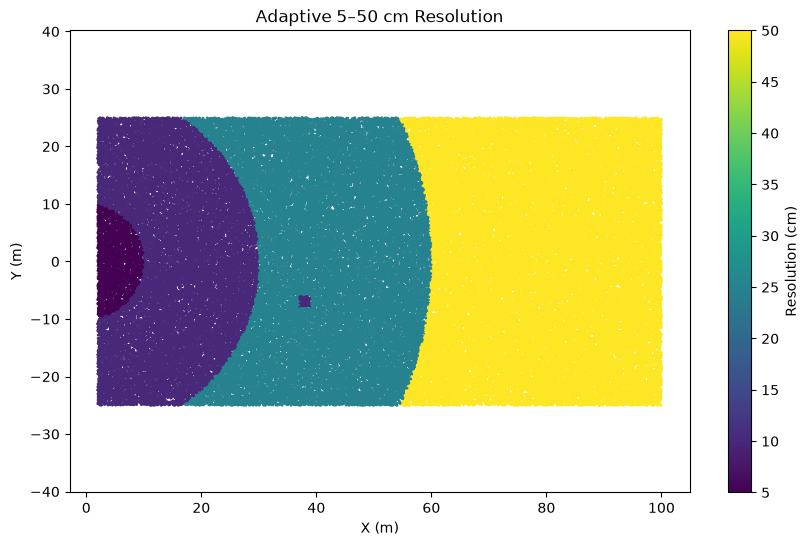

In [91]:
# Adaptive-resolution visualization
r = adaptive["resolutions"]
plt.figure(figsize=(10,6))
s = plt.scatter(xyz[:,0], xyz[:,1], c=r*100, s=1)
plt.colorbar(s, label="Resolution (cm)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Adaptive 5–50 cm Resolution")
plt.axis("equal")
plt.show()


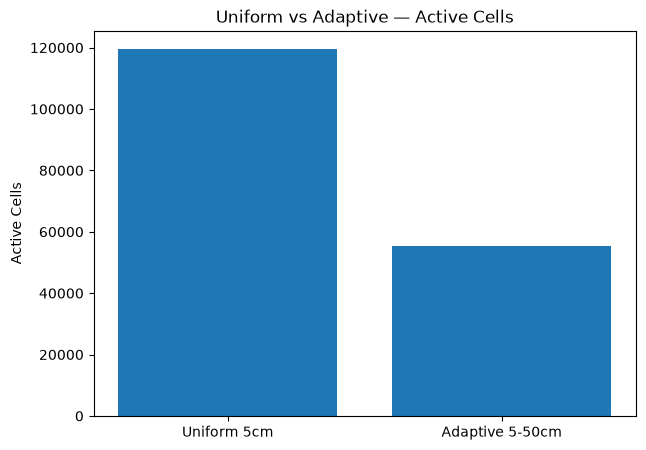

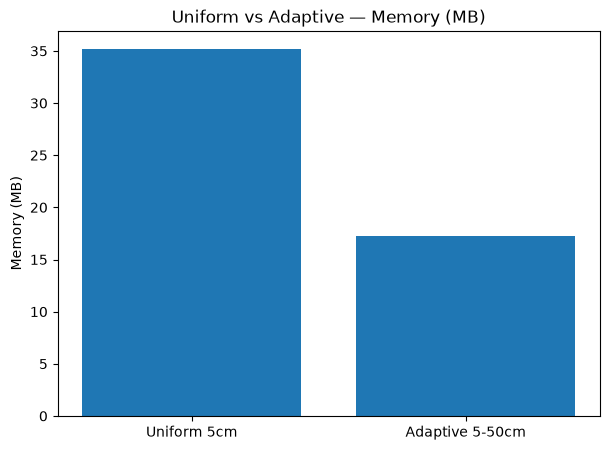

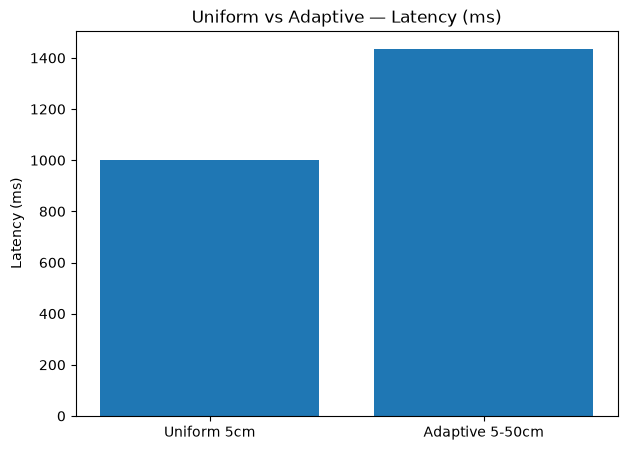

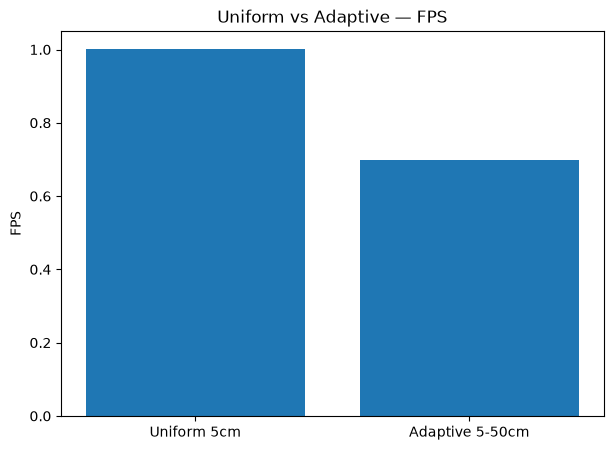

In [92]:
# Uniform vs adaptive graphs
for metric, title in [
    ("cells", "Active Cells"),
    ("memory_mb", "Memory (MB)"),
    ("latency_ms", "Latency (ms)"),
    ("fps", "FPS")
]:
    plt.figure(figsize=(7,5))
    plt.bar(["Uniform 5cm", "Adaptive 5-50cm"],
            [uniform[metric], adaptive[metric]])
    plt.ylabel(title)
    plt.title("Uniform vs Adaptive — " + title)
    plt.show()


In [93]:
# Save results
results.to_csv(RESULTS_DIR/"benchmark.csv", index=False)
distance_df.to_csv(RESULTS_DIR/"distance_analysis.csv", index=False)
object_test.to_csv(RESULTS_DIR/"object_test.csv", index=False)

pd.DataFrame({
    "method": ["Uniform 5cm", "Adaptive 5-50cm"],
    "latency_ms": [uniform["latency_ms"], adaptive["latency_ms"]]
}).to_csv(RESULTS_DIR/"latency.csv", index=False)

pd.DataFrame({
    "method": ["Uniform 5cm", "Adaptive 5-50cm"],
    "memory_mb": [uniform["memory_mb"], adaptive["memory_mb"]]
}).to_csv(RESULTS_DIR/"memory.csv", index=False)

print("Saved results to:", RESULTS_DIR.resolve())


Saved results to: E:\code\pr\LIDAR\results


## Final pipeline

LiDAR → preprocessing → AI segmentation → object detection → 2.5D map → adaptive resolution → real-time optimization → validation/dashboard.

The key milestone from the supplied roadmap is one real `.bin` frame successfully passing through classified points, detected objects, a 2.5D map and an adaptive 5–50 cm map. fileciteturn0file0L691-L695